## Load Data

In this section, we'll load the MNIST dataset. We will use the training set for database items, and the test set as incoming queries.

In [4]:
import torch.utils.data as util_data
from torchvision import transforms
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import torchvision.datasets as dsets
import torch.multiprocessing
import scipy.spatial.distance
torch.multiprocessing.set_sharing_strategy('file_system')

We will load data using the pytorch library. However, we will convert everything into numpy for LSH. Later, we will also train a hash function for searching.

In [5]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, ), (0.5, ))
    ])

# train_dataset = dsets.CIFAR10(root='./', train=True, transform=transform, download=True)
# test_dataset = dsets.CIFAR10(root='./', train=False, transform=transform)

train_dataset = dsets.MNIST(root='./', train=True, transform=transform, download=True)
test_dataset = dsets.MNIST(root='./', train=False, transform=transform)

train_dataloader = util_data.DataLoader(train_dataset,
                                        batch_size=16,
                                        pin_memory=True,
                                        shuffle=False, num_workers=2)
test_dataloader = util_data.DataLoader(test_dataset,
                                        batch_size=16,
                                        pin_memory=True,
                                        shuffle=False, num_workers=2)

100.0%
100.0%
100.0%
100.0%


In [6]:
def get_numpy_data(dataloader):
    x, y = [], []
    for batch_x, batch_y in tqdm(iter(dataloader)):
        x.append(batch_x.numpy())
        y.append(batch_y.numpy())
    x = np.vstack(x)
    y = np.concatenate(y)

    return x, y

def one_hot_label(single_label, num_label=None):
    if num_label is None:
        num_label = np.max(single_label)+1
    num_samples = single_label.size
    one_hot_label = np.zeros([num_samples, num_label], int)
    for i in range(num_samples):
        one_hot_label[i, single_label[i]] = 1
    return one_hot_label

In [7]:
# Convert pytorch tensors to numpy arrays (tensor == array)
db_x, db_y = get_numpy_data(train_dataloader)
query_x, query_y = get_numpy_data(test_dataloader)

c:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\hieuenv\lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 625/625 [00:09<00:00, 66.83it/s] 


In [8]:
# For easier computation, we'll only use the first 1k queries
db_x = db_x.reshape([db_x.shape[0], -1])
query_x = query_x.reshape([query_x.shape[0], -1])

query_x = query_x[:1000,]
query_y = query_y[:1000]

N_db, D = db_x.shape
N_query = query_x.shape[0]

print(f'DB has {N_db} items, there are {N_query} incoming queries!')

DB has 60000 items, there are 1000 incoming queries!


## LSH with Cosine Similarity

Reminder, we first "hash" the raw input to discrete space where locality is preserved. With Cosine Similarity, we hash each data point using which side it is on w.r.t a random hyperplane, where each hyperplane will define a new dimension of the new discrete 0-1 space.

In [9]:
nbits = 100 #number of random projections

Complete the following steps:

- Create a collection of random vectors (Hint: you can use np.random.randn)

- Project both the query and db into a new discrete space using the random vectors

- Discretize the elements by setting all positive elements to 1 and non-positive ones to 0

In [10]:
# YOUR CODE HERE

# Create a collection of random vectors
random_proj = np.random.randn(D, nbits)

# Project both the query and db into a new discrete space using the random vectors
query_proj = query_x @ random_proj
db_proj = db_x @ random_proj

# Discretize the elements
db_proj_b = (db_proj > 0).astype(int)
query_proj_b = (query_proj > 0).astype(int)

Let's take a pair of samples and see whether the distances are well approximated in this discrete space

In [11]:
sampleX_ID = 10
otherX_ID = 200
sampleX, sampleY = db_x[sampleX_ID, :], db_y[sampleX_ID]
otherX, otherY = db_x[otherX_ID, :], db_y[otherX_ID]
sampleX_b, otherX_b = db_proj_b[sampleX_ID, :], db_proj_b[otherX_ID, :]
print(f'Labels of 2 points: {sampleY} and {otherY}')

# True distance is distance in the original space
true_distance = scipy.spatial.distance.cosine(sampleX, otherX)

# Approx distance after hashing
approx_distance = 2 * (sampleX_b != otherX_b).sum() / nbits # x2 putting it into the range of cosine distance

print(f'True Distance = {true_distance}, Approx Distance = {approx_distance}') 

Labels of 2 points: 3 and 1
True Distance = 0.18047338724136353, Approx Distance = 0.38


#### Running LSH

In [12]:
b = 10
r = 10

db_proj_b = db_proj_b.reshape([-1, b, r])
query_proj_b = query_proj_b.reshape([-1, b, r])

In [13]:
def hash_bands_boolean(B):
  # Hash function for each band
  N, b, r = B.shape
  vals = 2**np.repeat([np.repeat([np.arange(r)], b, axis=0)], N, axis=0)
  return np.multiply(B, vals).sum(-1)

In [14]:
# Hash each band into buckets
db_hashed = hash_bands_boolean(db_proj_b)
query_hashed = hash_bands_boolean(query_proj_b)

In [15]:
# Now, let's find matches for each query
# Reminder: if one of the band matches, it's a candidate
matches = []
# YOUR CODE HERE
for q_hash in query_hashed:
    match_mask = (db_hashed == q_hash).any(axis=1)
    matches.append(np.where(match_mask)[0])

In [16]:
# Extracting candidates, we will now use the labels as ground truth correct matches.
# For example: if a query's label matches that of the candidate's label, then LSH returns a good candidate
# otherwise it's a bad candidate
results = {} # key: query_id, value: a 2-element list [good_candidate_count, bad_candidate_count]
# YOUR CODE HERE
for q_idx, candidate_indices in enumerate(matches):
    q_label = query_y[q_idx]
    candidate_labels = db_y[candidate_indices]
    
    good_count = np.sum(candidate_labels == q_label)
    bad_count = len(candidate_labels) - good_count
    
    results[q_idx] = [good_count, bad_count]

In [17]:
# In practice, we usually determine the goodness of a search algorithm using precision.
# Precision = how many correct results among all returned results.
# In our context, it'll be how many "good candidates" are among all candidates. In this section, your task is to calculate the precision for each query.
precisions = [] # record precision for each query
num_candidates = []
# YOUR CODE HERE
for good, bad in results.values():
    total = good + bad
    num_candidates.append(total)
    if total > 0:
        precisions.append(good / total)
    else:
        precisions.append(0.0)

In [18]:
print(f'Average Precision: {np.mean(precisions)}')

Average Precision: 0.12720755680143034


You may find that it is quite low. But don't be surprised, this is merely a list of candidate items. In practice, any search system will have an additional step to re-rank the candidate items. Remember, this is still significantly better than O(n) comparisons with everything in the database. Let's now determine how many candidate items there are for each query.

In [19]:
print(f'Average number of candidates per query {np.mean(num_candidates)}, number of items in DB {N_db}')

Average number of candidates per query 26614.227, number of items in DB 60000


# Application: Finding duplicate items

We'll use database items only

In the next cell, retrieve items that are potentially duplicates by selecting elements in db_hashed which appear more than once

In [29]:
candidates = []
# YOUR CODE HERE
unique_hashes, inverse_indices, counts = np.unique(db_hashed, axis=0, return_inverse=True, return_counts=True)
duplicate_hash_indices = np.where(counts > 1)[0]
for dh_idx in duplicate_hash_indices:
    item_indices = np.where(inverse_indices == dh_idx)[0]
    candidates.append(item_indices)

Let's inspect some pair of candidates

In [30]:
from PIL import Image as im
from matplotlib import pyplot as plt

In [31]:
candidates[0]

array([13227, 42179])

In [50]:
idx1, idx2 = candidates[5][0], candidates[5][1]

In [51]:
image1 = db_x[idx1,].reshape([1, 28, 28]).transpose([2,1,0])
image2 = db_x[idx2,].reshape([1, 28, 28]).transpose([2,1,0])

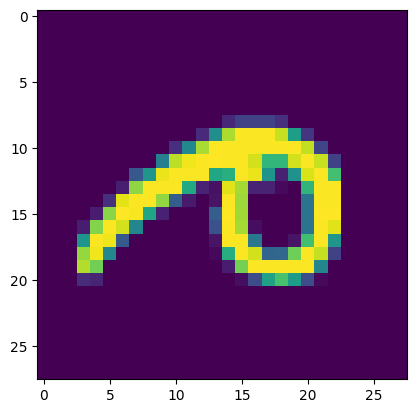

In [52]:
plt.imshow(image1)

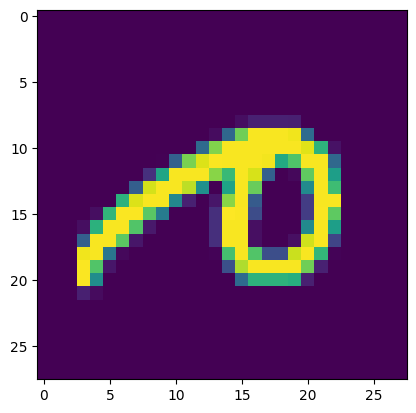

In [53]:
plt.imshow(image2)